$$
\huge \text{De Píxel a Polígono:}
\atop
\large \text{Reconstrucción Tridimensional de Objetos a Partir de Captura de Múltiples Vistas Fija}
$$

In [12]:
!pip install pyvista pyvistaqt opencv-python numpy matplotlib scipy scikit-image onnxruntime

In [1]:
import os

import cv2 as cv

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from scipy.spatial import cKDTree
import pyvista as pv
import rembg

# 1. Preprocesado

En esta etapa inicial, el objetivo es preparar las imágenes crudas para maximizar la fidelidad de la posterior reconstrucción geométrica.

1.  **Corrección Gamma**: Aplicamos una transformación de potencia **(gamma)** para modificar el contraste de la imagen. Un valor de **gamma > 1.0** oscurece la imagen, realzando los detalles en zonas de sombra y aumentando el contraste entre el objeto y el fondo. Esto facilita enormemente la tarea de segmentación.

2.  **Eliminación de Fondo (Segmentation)**: Utilizamos la librería `rembg`, que implementa, entre otras, la arquitectura de red neuronal **U2Net**. Esta red genera una máscara de transparencia (canal Alpha) de alta precisión.

3.  **Guardado**: Las imágenes procesadas se guardan en formato PNG (que soporta transparencia) para ser utilizadas en las etapas de extracción de características.

In [2]:
SAMPLES_DIR = 'Samples'
SAMPLE_BASE_PATH = os.path.join(SAMPLES_DIR, '09_Samples')
SAMPLE_STATE_00  = os.path.join(SAMPLE_BASE_PATH, '00_state')
IMAGES = []

print("Cargando imágenes...")
# Procesamos todas las imágenes encontradas en el directorio
for i in range(1, len(os.listdir(SAMPLE_STATE_00)) + 1):
    print(f"|-> Procesando imagen {i:02d} de {len(os.listdir(SAMPLE_STATE_00))}", end='\r')
    file_path = os.path.join(SAMPLE_STATE_00, f"{i:02d}_model.jpeg")

    IMAGES.append(cv.imread(file_path, cv.IMREAD_COLOR_RGB))
print("Imágenes cargadas correctamente.")

Cargando imágenes...
Imágenes cargadas correctamente.


## 1.1 Funciones de Preprocesado

Para automatizar el proceso, definimos dos funciones clave:
*   `apply_gamma(img, g)`: Aplica una corrección gamma a los píxeles de la imagen.
    *   La fórmula aplicada es $V_{out} = V_{in}^{\gamma}$.
    *   Si $\gamma > 1$, la imagen se oscurece, lo que ayuda a separar visualmente el objeto del fondo, siendo este muy oscuro
    *   Si $\gamma < 1$, la imagen se aclara.
*   `remove_background(img_rgba, session, gamma)`: Orquesta el proceso completo para una imagen:
    1.  **Pre-procesado**: Aplica la corrección gamma a una copia de la imagen para mejorar el contraste.
    2.  **Inferencia**: Pasa la imagen mejorada a `rembg` para predecir la máscara de recorte.
    3.  **Aplicación**: Aplica la máscara generada a la imagen **original** (sin la corrección gamma).

In [3]:
def apply_gamma(img, gamma):
    img_f = img.astype(np.float32) / 255.0
    img_f = np.clip(np.power(img_f, gamma), 0.0, 1.0)
    return (img_f * 255).astype(np.uint8)

def remove_background(img, session, gamma=1.0):
    img_copy = img.copy()

    img_enhanced = apply_gamma(img_copy, gamma)
    mask = rembg.remove(img_enhanced, session=session, only_mask=True)
    
    rgba = np.dstack((img, mask))
    rgba[mask == 0] = 0
    return rgba

## 1.2 Experimentación

### 1.2.1: Benchmark de Gamma
Para evaluar la eficacia de los distintos niveles de contraste y automatizar la validación visual, implementamos la función de benchmarking:

* `benchmark_gamma(images, gammas)`: Genera una matriz de visualización comparativa para determinar empíricamente el valor óptimo de $\gamma$.
    * **Muestreo Estratégico**: Selecciona un subconjunto representativo del dataset (1 de cada 11 imágenes) mediante `images[0::11]`, evitando la sobrecarga de procesar todo el conjunto para la prueba.
    * **Visualización (Grid)**: Construye una cuadrícula dinámica con `matplotlib` donde:
        1.  **Fila 0 (Referencia)**: Muestra las imágenes originales sin procesar.
        2.  **Filas $1...N$ (Resultados)**: Cada fila subsiguiente muestra el resultado de `remove_background` aplicado con un valor específico de la lista `gammas`.

In [4]:
def benchmark_gamma(images, gammas): 
    default_rembg_session = rembg.new_session("u2net") 

    selected_images = images[0::11]
    rows, cols = len(gammas) + 1, len(selected_images)
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 4 * rows)) 
    fig.suptitle("Benchmark diferentes valores de gamma, 1 imagen cada 11", fontsize=20)

    for i, img_rgb in enumerate(selected_images): 
        axes[0, i].imshow(img_rgb) 
        axes[0, i].axis('off') 
        if i == cols // 2: 
            axes[0, i].set_title("Original", fontsize=16) 

        for j, g in enumerate(gammas): 
            img_no_bg = remove_background(img_rgb, default_rembg_session, gamma=g) 

            axes[j+1, i].imshow(img_no_bg) 
            axes[j+1, i].axis('off') 
            if i == cols // 2: 
                axes[j+1, i].set_title(f"Gamma {g}", fontsize=16) 

    plt.tight_layout()
    plt.show()

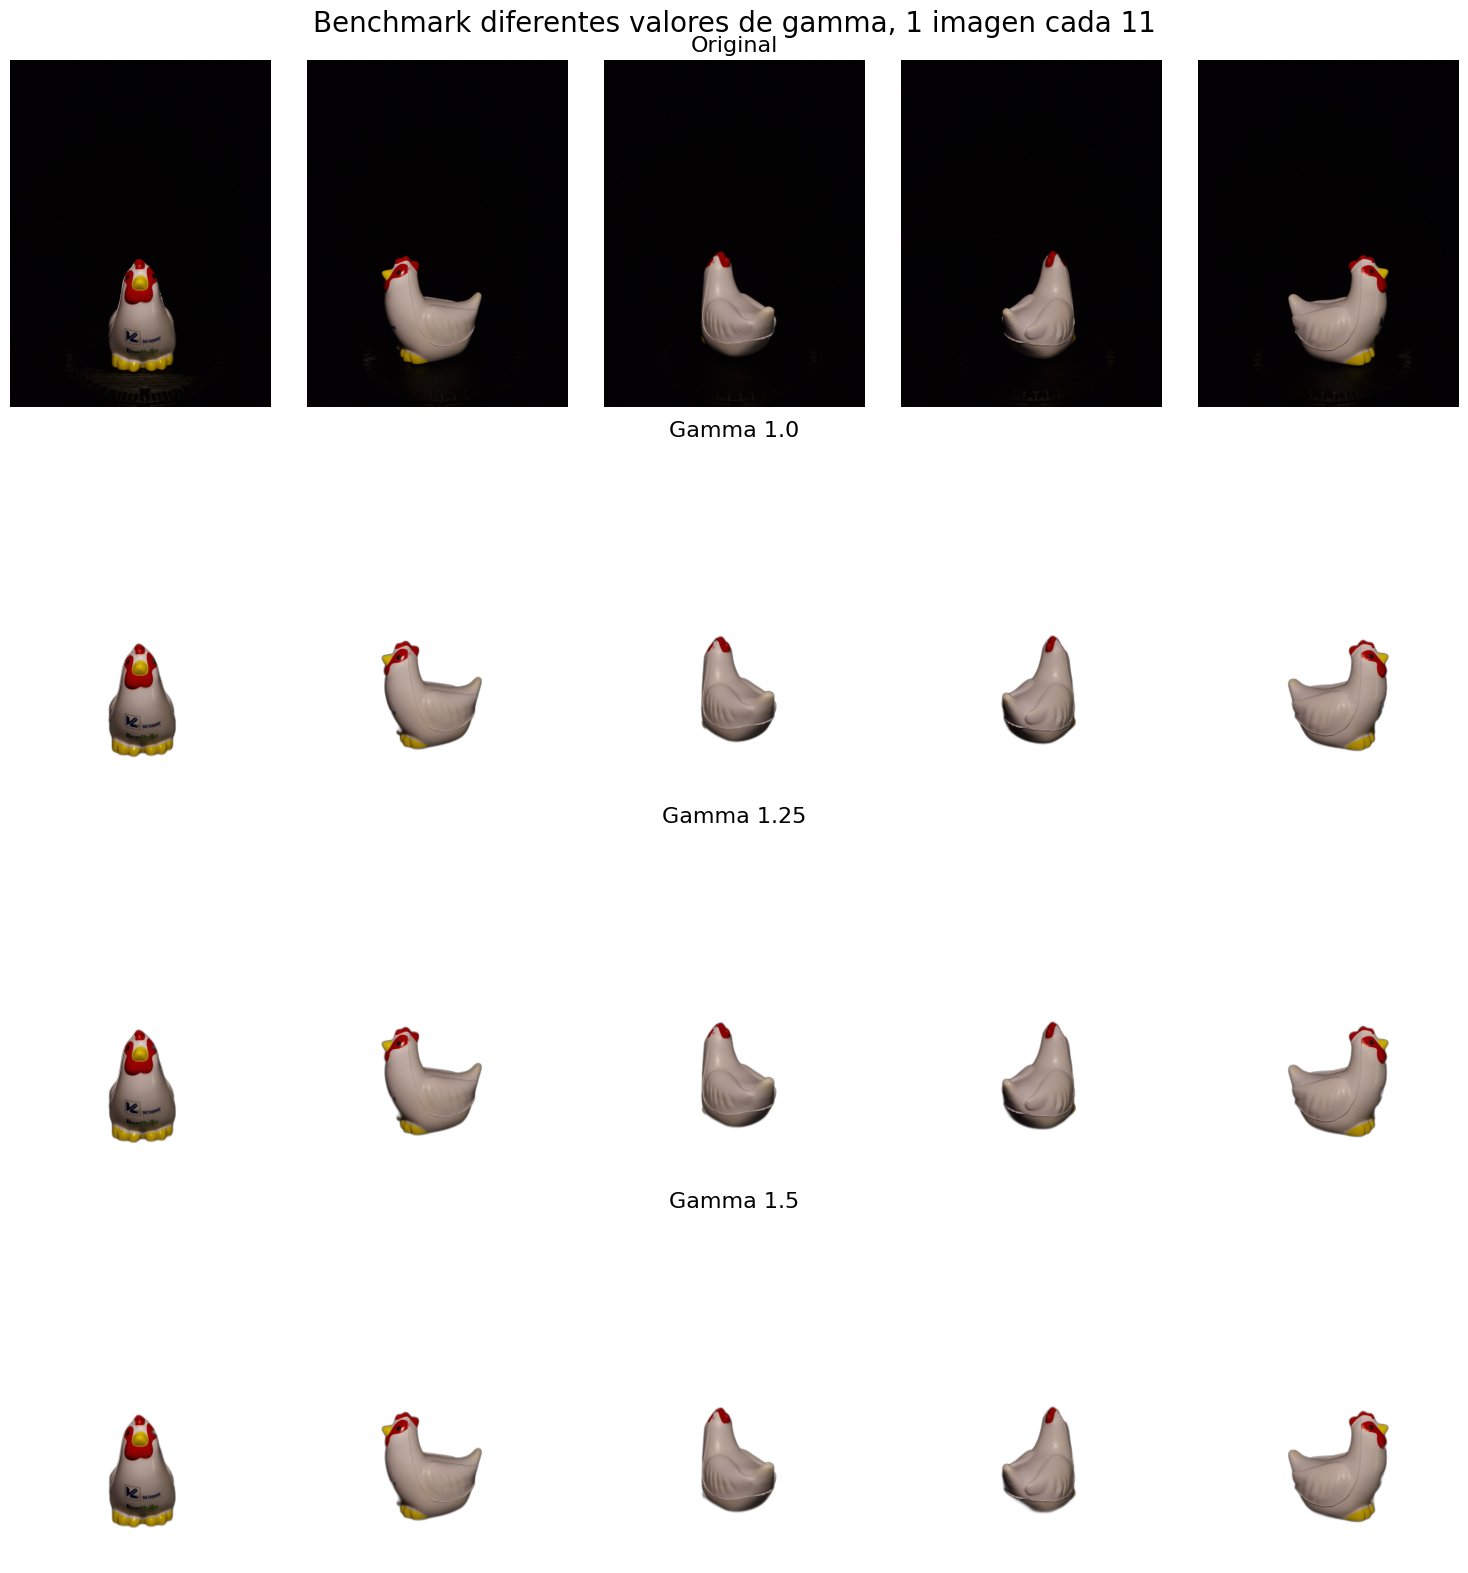

In [5]:
benchmark_gamma(IMAGES, [1.0, 1.25, 1.5] )

Usaremos el valor $\gamma=1.25$, dado que nos da un margen razonable de prevención de fallos asociados a la visualización del stand que usamos. En este benchmark no se visualiza muy bien, pero experimentalmente hemos comprobado que algunas de las imágenes presentan restos del stand junto con el objeto cuando el valor $\gamma=1$ 

In [6]:
GAMMA = 1.25

### 1.2.2 Selección de Modelo de Segmentación
Para complementar el ajuste de gamma, es necesario validar qué arquitectura de red neuronal ofrece el mejor rendimiento. Para ello definimos:

* `benchmark_rembg_models(images, gamma)`: Realiza una comparativa directa entre los distintos modelos disponibles en `rembg` (como *u2net*, *u2netp*, *isnet*) manteniendo el gamma fijo.
    * **Gestión Eficiente de Sesiones**: Crea y almacena las sesiones en un diccionario (`sessions`) *antes* de iniciar el procesamiento. 
    * **Matriz de Evaluación**: Genera una visualización donde:
        1.  **Fila 0 (Referencia)**: Muestra la imagen original.
        2.  **Filas $1...N$ (Modelos)**: Cada fila subsiguiente muestra el recorte generado por un modelo específico (`u2net`, `u2netp`, etc.).

In [7]:
def benchmark_rembg_models(images, gamma):
    model_names = ["u2net", "u2netp", "isnet-general-use"]
    
    selected_images = images[0::11]
    # Pre-cargamos sesiones para evitar recrearlas en el bucle interno
    sessions = {name: rembg.new_session(name) for name in model_names}
    
    rows, cols = len(model_names) + 1, len(selected_images)

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 4 * rows)) 
    fig.suptitle("Benchmark diferentes modelos de IA de gamma, 1 imagen cada 11", fontsize=20)

    for i, img in enumerate(selected_images):
        # 1. Original
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        if i == len(selected_images) // 2:
            axes[0, i].set_title("Original", fontsize=16)

        # 2. Modelos
        for j, name in enumerate(model_names):
            res = remove_background(img, sessions[name], gamma=gamma)
            
            axes[j+1, i].imshow(res)
            axes[j+1, i].axis('off')
            if i == len(selected_images) // 2:
                axes[j+1, i].set_title(name, fontsize=16)

    print("\nBenchmark finalizado.")
    plt.tight_layout()
    plt.show()


Benchmark finalizado.


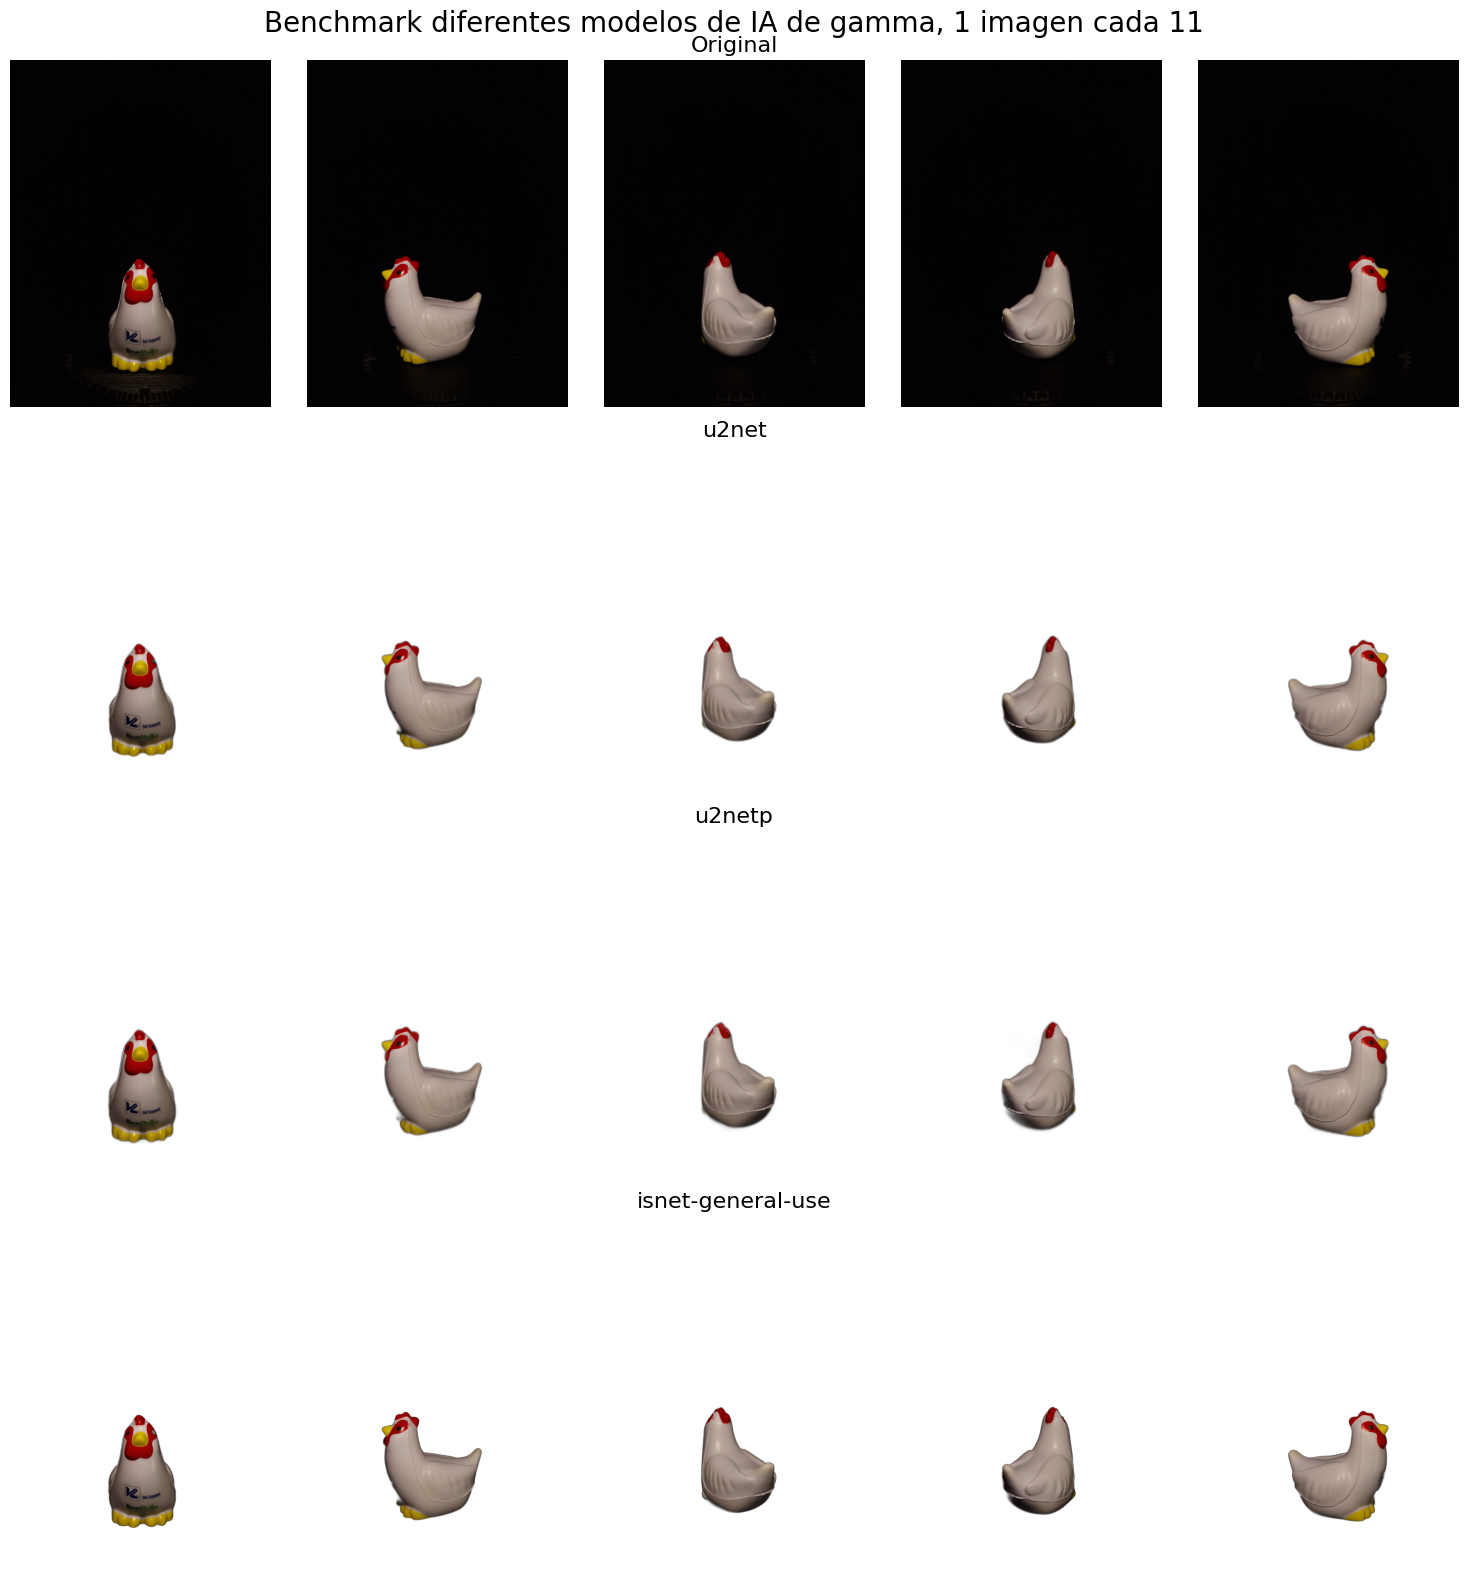

In [8]:
benchmark_rembg_models(IMAGES, GAMMA)

El modelo estándar ,**`u2net`**, combinado con nuestro ajuste de gamma proporciona resultados satisfactorios, por lo que procedemos con esta configuración.

In [9]:
REMBG_SESSION = rembg.new_session("u2net")

## 1.3 Ejecución del Pipeline de Preprocesado

Con los parámetros definidos ($\gamma$ = 1.25), ejecutamos el procesamiento por lotes para todo el dataset.

El script iterará sobre todas las imágenes cargadas:
1.  Aplicará la eliminación de fondo con la configuración óptima.
2.  Convertirá el resultado al espacio de color BGRA (requerido por OpenCV para guardar).
3.  Guardará los archivos `.png` resultantes en el directorio de salida (`01_state`), listos para la extracción de características.

In [10]:
IMAGES_BGLESS = []
SAMPLE_STATE_01  = os.path.join(SAMPLE_BASE_PATH, '01_state')

print("Iniciando procesamiento...")
for i, img_rgba in enumerate(IMAGES):
    final_img = remove_background(img_rgba, REMBG_SESSION, gamma=GAMMA)
    IMAGES_BGLESS.append(final_img)
    
    filename = f"{i+1:02d}_model.png"
    out_path = os.path.join(SAMPLE_STATE_01, filename)
    cv.imwrite(out_path, final_img)
    print(f"|-> Procesada imagen: {filename}", end='\r')

print("")
print('Procesamiento completado.')

Iniciando procesamiento...


KeyboardInterrupt: 

# 2. Extracción y detección de características

## 2.1 Algoritmo SIFT (Scale-Invariant Feature Transform)

Para la reconstrucción 3D, es fundamental encontrar puntos correspondientes ("matches") entre pares de imágenes consecutivas que representen la misma parte física del objeto. Utilizamos el algoritmo **SIFT** (Scale-Invariant Feature Transform).


**¿Por qué usamos SIFT?**

A diferencia de detectores más simples (como Harris Corners), SIFT es capaz de detectar y describir características locales ("keypoints") que son robustas frente a:
*   **Escala**: Reconoce el mismo detalle aunque el objeto esté más cerca o más lejos (gracias al espacio de escala gaussiano).
*   **Rotación**: Es invariante a la rotación de la imagen.
*   **Iluminación**: Es parcialmente invariante a cambios de intensidad lumínica.

En nuestra implementación usamos `cv.SIFT_create` con:
*   `contrastThreshold=0.02`: Un umbral bajo para detectar características incluso en zonas de bajo contraste (texturas suaves).
*   `edgeThreshold=10`: Para filtrar características que se encuentran en bordes (que son difíciles de localizar con precisión).

**El flujo de trabajo de Matching:**

1.  **Detección y Descripción**: Calculamos los keypoints y sus descriptores (vectores de 128 dimensiones) para ambas imágenes.
2.  **Matching (Emparejamiento)**: Utilizamos `BFMatcher` (Brute Force Matcher) con la norma L2 (distancia euclidiana). Usamos el método `knnMatch` con $k=2$, lo que significa que para cada punto de la imagen A, buscamos los **dos** mejores candidatos en la imagen B.
3.  **Filtrado (Lowe's Ratio Test)**: Si el mejor match es muy similar al segundo mejor (distancias parecidas), el emparejamiento es ambiguo y probablemente erróneo
    *   Sea $d_1$ la distancia al mejor match y $d_2$ la distancia al segundo mejor.
    *   Aceptamos el match solo si $d_1 < 0.75 \cdot d_2$.

In [ ]:
def feature_and_matching(im1, im2):
    """
    Detecta características SIFT y realiza emparejamiento rápido con FLANN.
    
    Args:
        im1, im2: Imágenes de entrada (en color o gris).
        
    Returns:
        pts1, pts2: Arrays numpy con las coordenadas de los puntos coincidentes.
        kp1, kp2: Keypoints originales.
        good_matches: Lista de objetos DMatch filtrados.
    """
    # 1. Detección SIFT
    sift = cv.SIFT_create(contrastThreshold=0.02, edgeThreshold=10)
    kp1, des1 = sift.detectAndCompute(im1, None)
    kp2, des2 = sift.detectAndCompute(im2, None)

    # 2. BFMatcher k=2 para poder aplicar el Ratio Test luego
    bf = cv.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    # 3. Filtrado con Lowe's Ratio Test
    # Se queda solo con matches donde la mejor coincidencia es mucho mejor que la segunda.
    good_matches = []
    ratio_threshold = 0.75
    
    for m, n in matches:
        if m.distance < ratio_threshold * n.distance:
            good_matches.append(m)

    # 4. Formateo de salida
    # Convertimos directamente a array numpy de float32 para usar en homografías
    pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    return pts1, pts2, kp1, kp2, good_matches

## 2.2 Ejecución y Visualización del Matching

A continuación, probamos la función con dos imágenes consecutivas del dataset procesado. Visualizaremos las líneas que conectan los puntos clave encontrados en ambas imágenes para verificar visualmente la calidad de los emparejamientos. Si las líneas son paralelas y coherentes, el matching es correcto; si hay muchas líneas cruzadas caóticas, el filtrado necesita ajuste.

In [ ]:
def visualize_matches(images):
    pairs = [(i, i+1) for i in range(0, len(images), 11)]
    cols, rows = 3, 2
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    fig.suptitle("Visualización de Matches entre pares de imágenes (muestreo cada 11)", fontsize=20)
    
    axes = axes.flatten()
    for idx, (idx1, idx2) in enumerate(pairs):
        img1, img2 = images[idx1], images[idx2]
        
        pts1, pts2, kp1, kp2, matches = feature_and_matching(img1, img2)
        res = cv.drawMatches(img1, kp1, img2, kp2, matches, None, flags=2)
        
        axes[idx].imshow(res)
        axes[idx].set_title(f"Match: {idx1+1:02d} -> {idx2+1:02d} ({len(matches)} matches)")
        axes[idx].axis('off')

    axes[5].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
visualize_matches(IMAGES_BGLESS)

# 3. Structure from Motion (SfM)

La técnica de **Structure from Motion (SfM)** permite reconstruir la estructura 3D de una escena a partir de un conjunto de imágenes 2D tomadas desde diferentes puntos de vista.

En este proyecto, asumimos un escenario de **"Turntable" (Plataforma Giratoria)**:
*   La cámara está fija (o se mueve en una órbita perfecta).
*   El objeto rota sobre su eje.
*   Esto nos permite simplificar el cálculo de la posición de las cámaras (Extrínsecas), ya que siguen una trayectoria circular predecible.

## 3.1 Algoritmo de Reconstrucción Circular

La función `Sfm_circular` implementa el núcleo de la reconstrucción. Sus pasos son:

1.  **Feature Matching**: Obtiene los puntos correspondientes entre dos imágenes consecutivas (usando la función SIFT definida anteriormente).
2.  **Validación Geométrica (Matriz Fundamental + RANSAC)**:
    *   Calculamos la **Matriz Fundamental ($F$)** que relaciona la geometría epipolar de las dos vistas.
    *   Utilizamos **RANSAC** (Random Sample Consensus) para estimar $F$. RANSAC selecciona subconjuntos aleatorios de puntos y busca el modelo que mejor se ajusta a la mayoría.
    *   **Filtrado**: Los puntos que no cumplen con la geometría epipolar (outliers) son descartados. Esto limpia drásticamente la nube de puntos de emparejamientos erróneos que pasaron el filtro de Lowe.
3.  **Estimación de Poses (Extrínsecas)**:
    *   En lugar de calcular la pose desde cero, calculamos la matriz de rotación $R$ y traslación $t$ basándonos en el índice de la imagen, asumiendo que las $N$ imágenes completan un círculo de 360°.
    *   $\theta = \text{idx} \cdot \frac{2\pi}{N}$
4.  **Triangulación**:
    *   Con las matrices de proyección $P_1 = K[R_1|t_1]$ y $P_2 = K[R_2|t_2]$ nos aseguramos que todas las triangulaciones se hacen sobre el mismo sistema de referencia, que sitúaq la posición de la primera cámara con Rotación y traslación nulas, proyectamos rayos desde los centros de las cámaras pasando por los píxeles emparejados.
    *   El punto 3D se encuentra en la intersección (o punto de mínima distancia) de estos rayos. Usamos `cv.triangulatePoints`.
5.  **Conversión a Euclídeo**: Convertimos las coordenadas homogéneas $(X, Y, Z, W)$ a cartesianas $(X/W, Y/W, Z/W)$.

In [ ]:
def Sfm_circular(im1, im2, K, idx1, idx2, n_imgs, rad, direction=1):
    # 1. Obtener Puntos Emparejados
    pts1, pts2, kp1, kp2, good_matches = feature_and_matching(im1, im2)
    
    # FILTRADO DE OUTLIERS CON RANSAC
    pts1 = np.ascontiguousarray(pts1)
    pts2 = np.ascontiguousarray(pts2)
    F, mask = cv.findFundamentalMat(pts1, pts2, cv.FM_RANSAC, 1.0, 0.99)
        
    # Aplicamos la máscara para quedarnos solo con los inliners
    mask = mask.ravel() == 1
    pts1 = pts1[mask]
    pts2 = pts2[mask]

    # Aseguramos que los puntos tengan forma (N, 2) para triangulatePoints
    pts1 = pts1.reshape(-1, 2)
    pts2 = pts2.reshape(-1, 2)

    # 2. Calcular Poses Absolutas de las Cámaras
    def get_pose(idx, N, R_dist, rot_dir):
        # Ángulo de rotación
        theta = rot_dir * idx * (2 * np.pi / N)
        
        # Rotación alrededor del eje Y
        c, s = np.cos(theta), np.sin(theta)
        R = np.array([
            [c, 0, s],
            [0, 1, 0],
            [-s, 0, c]
        ])
        
        t = np.array([[0], [0], [R_dist]])
        
        return R, t

    R1, t1 = get_pose(idx1, n_imgs, rad, direction)
    R2, t2 = get_pose(idx2, n_imgs, rad, direction)

    # Matrices de Proyección
    P1 = K @ np.hstack((R1, t1))
    P2 = K @ np.hstack((R2, t2))
    
    # 3. Triangulación 3D
    pts4d = cv.triangulatePoints(P1, P2, pts1.T, pts2.T)
    
    # Normalización homogénea, evitar división por cero
    w_coord = pts4d[3]
    w_coord[np.abs(w_coord) < 1e-6] = 1e-6
    
    pts3d = pts4d[:3] / w_coord
    
    # CORRECCIÓN DE EJE Z (Invirtiendo signo)
    pts3d[2] *= -1

    return pts3d.T.copy()

## 3.2 Calibración de Cámara y Corrección de Distorsión

Antes de triangular puntos 3D precisos, debemos corregir las deformaciones ópticas introducidas por la lente de la cámara.

*   **Matriz Intrínseca ($K$)**: Contiene la distancia focal ($f_x, f_y$) y el centro óptico ($c_x, c_y$). Define cómo se proyecta el mundo 3D en el plano de imagen 2D.
*   **Coeficientes de Distorsión**: Modelan la distorsión radial (efecto "ojo de pez") y tangencial.

El siguiente bloque de código aplica `cv.undistort` a todas las imágenes procesadas para "aplanarlas" matemáticamente, asegurando que las líneas rectas en el mundo real sean rectas en la imagen.

In [ ]:
P_LOW, P_HIGH = 1, 99  # Percentil inferior y superior para filtrado de outliners
HEIGHT, WIDTH = IMAGES_BGLESS[0].shape[:2]

# Matriz K calibrada (proporcionada)
K = np.array([
    [2.69889306e+03, 0.00000000e+00, 1.49789941e+03],
    [0.00000000e+00, 2.76369335e+03, 2.04250158e+03],
    [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]
])
dist_coeffs = np.array([0.15055201, -0.79565235, 0.00639867, -0.00277334, 1.94243501])

print("Aplicando corrección de distorsión a las imágenes...")
h, w = IMAGES_BGLESS[0].shape[:2]
    
# Ajustamos K para tener la deformación "estiramiento" de la imagen
K, roi = cv.getOptimalNewCameraMatrix(K, dist_coeffs, (WIDTH, HEIGHT), alpha=1, newImgSize=(WIDTH, HEIGHT))
    
IMAGES_UNDISTORTED = []
for img in IMAGES_BGLESS:
    dst = cv.undistort(img, K, dist_coeffs, None, K)
    IMAGES_UNDISTORTED.append(dst)
    
IMAGES_BGLESS = IMAGES_UNDISTORTED
print("Imágenes corregidas y Matriz K actualizada.")

Aplicando corrección de distorsión a las imágenes...
Imágenes corregidas y Matriz K actualizada.


## 3.3 Filtrado de la Nube de Puntos

La triangulación bruta suele generar ruido debido a pequeños errores en el matching o en la estimación de poses. Para limpiar la nube de puntos resultante, aplicamos dos filtros:

1.  **Statistical Outlier Removal (SOR)**:
    *   Para cada punto, calculamos la distancia media a sus $k$ vecinos más cercanos.
    *   Calculamos la media ($\mu$) y desviación estándar ($\sigma$) de estas distancias para toda la nube.
    *   Eliminamos cualquier punto cuya distancia media sea mayor que $\mu + \alpha \cdot \sigma$. Esto elimina puntos aislados ("nubes de polvo") que no forman parte de la superficie densa.
2.  **Filtrado de Caja (Percentiles)**:
    *   Calculamos los límites de la caja que contiene el 80-90% central de los puntos.
    *   Recortamos los puntos que caen fuera de esta caja para eliminar outliers extremos lejanos.

In [ ]:
def clean_pcd_statistical(points, nb_neighbors=20, std_ratio=2.0):
    # 20 distancias mas cercanas ordenadas
    d, _ = cKDTree(points).query(points, k=nb_neighbors + 1)
    
    # 'mu' es la media de distancias locales
    mu = np.mean(d[:, 1:], axis=1)
    
    # Filtro: mantiene puntos donde la distancia media local es menor al umbral
    return points[mu < np.mean(mu) + std_ratio * np.std(mu)]

def procesar_reconstruccion_sfm(images, K, p_low=10, p_high=90):
    print(f"--- INICIO DE RECONSTRUCCIÓN SFM (CIRCULAR) ---")
    
    puntos_3d = np.zeros((0, 3))
    n_imgs = len(images)
    
    # Radio estimado (distancia al objeto). DIRECCIÓN DE ROTACIÓN:-1: Horario (o cámara antihoraria)
    RADIO = 2.0
    DIRECTION = -1

    for i in range(n_imgs):
        idx1, idx2 = i, (i + 1) % n_imgs
        img1, img2 = images[idx1], images[idx2]

        # Usamos la nueva función con poses absolutas y dirección
        puntos = Sfm_circular(img1, img2, K, idx1, idx2, n_imgs, rad=RADIO, direction=DIRECTION)
        puntos_3d = np.vstack((puntos_3d, puntos))
            
        print(f"|-> Procesado par {idx1}-{idx2}: +{len(puntos)} puntos.", end='\r')
    
    print(f"\nTotal puntos generados (bruto): {len(puntos_3d)}")

    print(f"--- FILTRADO DE PUNTOS ---")

    mascara_validos = np.isfinite(puntos_3d).any(axis=1)
    puntos_limpios = puntos_3d[mascara_validos]
    print(f"Puntos tras eliminar Inf/NaN: {len(puntos_limpios)}")

    # 1. Filtrado Estadístico (SOR) - NUEVO
    print("Aplicando Statistical Outlier Removal (SOR)...")
    puntos_sor = clean_pcd_statistical(puntos_limpios, nb_neighbors=50, std_ratio=1.0)
    print(f"Puntos tras SOR: {len(puntos_sor)} (Eliminados: {len(puntos_limpios) - len(puntos_sor)})")


    # 2. Filtrado de Caja (Percentiles)
    # Elimina puntos muy lejanos que hayan sobrevivido al SOR
    min_x, max_x = np.percentile(puntos_sor[:, 0], [p_low, p_high])
    min_y, max_y = np.percentile(puntos_sor[:, 1], [p_low, p_high])
    min_z, max_z = np.percentile(puntos_sor[:, 2], [p_low, p_high])

    filtro_percentil = (
        (puntos_sor[:, 0] > min_x) & (puntos_sor[:, 0] < max_x) &
        (puntos_sor[:, 1] > min_y) & (puntos_sor[:, 1] < max_y) &
        (puntos_sor[:, 2] > min_z) & (puntos_sor[:, 2] < max_z) 
    )
    puntos_finales = puntos_sor[filtro_percentil]
    print(f"Puntos tras FIltrado de caja: {len(puntos_finales)} (Eliminados: {len(puntos_sor) - len(puntos_finales)})")
    
    return puntos_finales

In [ ]:
# 1. Ejecutar el procesamiento
puntos_finales = procesar_reconstruccion_sfm(IMAGES, K, p_low=P_LOW, p_high=P_HIGH)

# 2. Visualización
fig = go.Figure(data=[go.Scatter3d(
    x=puntos_finales[:,0],
    y=puntos_finales[:,1],
    z=puntos_finales[:,2],
    mode='markers',
    marker=dict(
        size=3,
        color=puntos_finales[:,2], # Colorear por profundidad (Z)
        colorscale='Hot',
        opacity=0.8
    )
)])

fig.update_layout(
    title=f"Nube de Puntos 3D ({len(puntos_finales)} puntos)",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    margin=dict(l=0, r=0, b=0, t=30)
)

fig.show()
print(puntos_finales)

--- INICIO DE RECONSTRUCCIÓN SFM (CIRCULAR) ---
|-> Procesado par 54-0: +104 puntos..
Total puntos generados (bruto): 5013
--- FILTRADO DE PUNTOS ---
Puntos tras eliminar Inf/NaN: 5013
Aplicando Statistical Outlier Removal (SOR)...
Puntos tras SOR: 4974 (Eliminados: 39)
Puntos tras FIltrado de caja: 4676 (Eliminados: 298)


[[-0.23800458  1.10415006 -0.28591555]
 [-0.22356944  1.16764796 -0.33896494]
 [-0.16876322  1.16936529 -0.36400574]
 ...
 [ 0.21804959  1.01470208 -0.68066615]
 [ 0.25659034  1.08094132 -0.3549583 ]
 [ 0.27365473  1.15369773 -0.35395622]]


# 4. Generación de Malla y Visualización

Una vez obtenida la nube de puntos limpia, el paso final es reconstruir la superficie (malla) del objeto.

1.  **Meshing (Delaunay 3D)**: Utilizamos la triangulación de Delaunay para conectar los puntos y formar tetraedros, extrayendo luego la superficie externa (`extract_surface`).
2.  **Texturizado**: Mapeamos una textura sobre la malla generada. En este ejemplo, utilizamos una textura de prueba (`masonry_texture`), pero en un flujo completo se proyectarían las imágenes originales sobre la malla.
3.  **Visualización**: Usamos `pyvista` para renderizar interactivamente la malla 3D y la nube de puntos original.

/home/luismi/Escritorio/4-TI/PID/PROYECTO_PID/PID/.venv/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:56: UserWarning:

Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/luismi/Escritorio/4-TI/PID/PROYECTO_PID/PID/.venv/lib/python3.13/site-packages/trame/widgets/__init__.py)

Falling back to a static output.



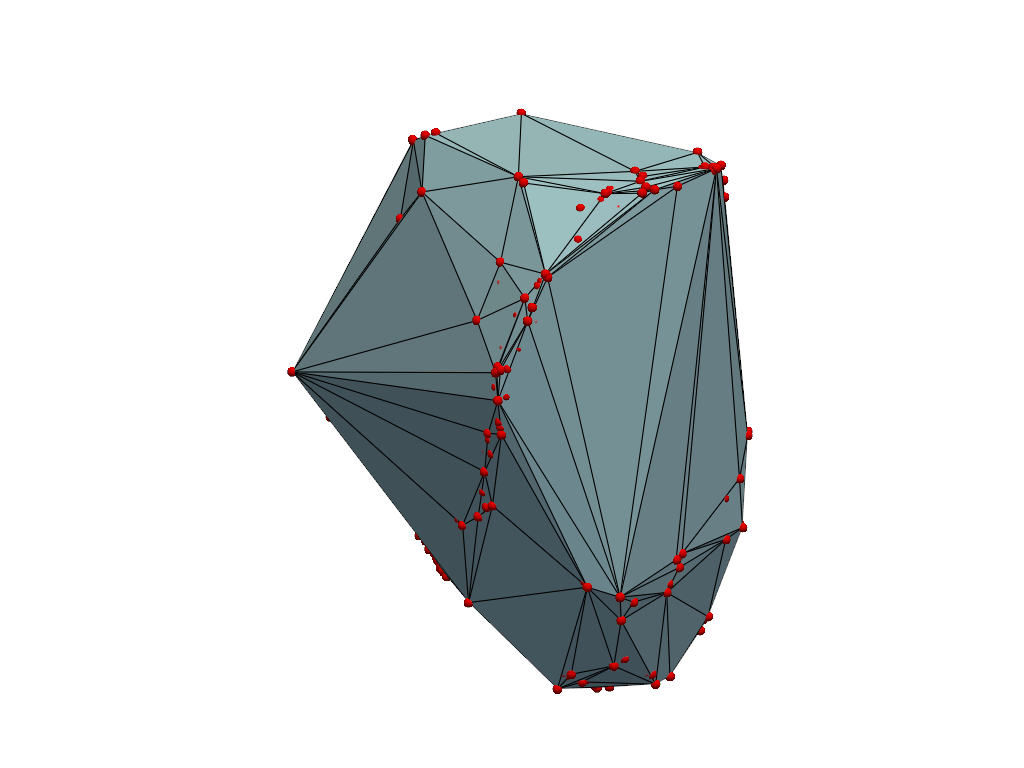

In [ ]:
cloud = pv.PolyData(puntos_finales)
##--- 1. GENERAR LA MALLA (Meshing) ---
mesh = cloud.delaunay_3d(alpha=0).extract_surface()

#--- 2. TEXTURIZADO Y MAPEO UV ---
mesh.texture_map_to_sphere(inplace=True)
mesh.texture_map_to_plane(inplace=True) 
tex = pv.examples.download_masonry_texture()

#--- 3. VISUALIZACIÓN ---
plotter = pv.Plotter()
plotter.add_mesh(mesh, cmap="viridis", show_edges=True) # show_edges ayuda a ver la geometría creada por la triangulación de Delaunay
plotter.add_points(cloud, color="red", point_size=10, render_points_as_spheres=True) # Ver puntos originales
plotter.show()